In [ ]:
import pandas as pd
import numpy as np 
import matplotlib. pyplot as plt
import seaborn as sns
import warnings
warnings, filterwarnings('ignore')


In [3]:
sns.set_style ("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv(r"C:\Users\thara\Desktop\churn_raw.csv")
print("shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

shape: (7043, 21)

First 5 rows:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("Data Types & Missing Values:")
print(df.info())

Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [13]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [20]:
df['Churn_Flag'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
def tenure_group(tenure):
    if tenure <= 6:
        return '0-6 Months'
    elif tenure <= 12:
        return '7-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 48:
        return '25-48 Months'
    else:
        return '49+ Months'
df['Tenure_Group'] = df['Tenure'].apply(tenure_group)

df['Customer_Type'] = df['Tenure'].apply(lambda x: 'New' if x <= 12 else 'Existing')

print("New columns added successfully!")
print(df[['CustomerID', 'Tenure', 'Tenure_Group', 'Churn', 'Churn_Flag', 'Customer_Type']].head())

New columns added successfully!
   CustomerID  Tenure  Tenure_Group Churn  Churn_Flag Customer_Type
0  7590-VHVEG       1    0-6 Months    No           0           New
1  5575-GNVDE      34  25-48 Months    No           0      Existing
2  3668-QPYBK       2    0-6 Months   Yes           1           New
3  7795-CFOCW      45  25-48 Months    No           0      Existing
4  9237-HQITU       2    0-6 Months   Yes           1           New


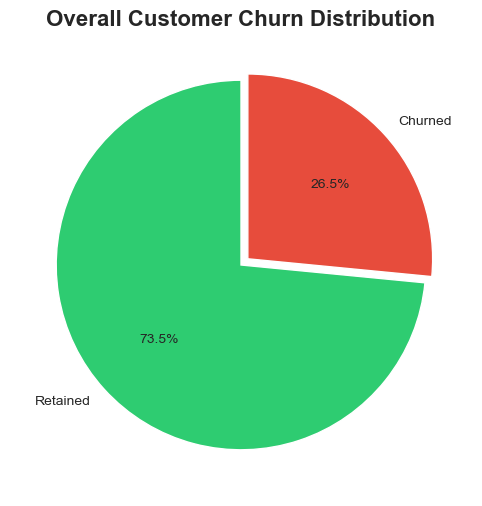

Chart 1 saved!


In [23]:
plt.figure(figsize = (8,6))
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71','#e74c3c']
plt.pie(churn_counts, labels =['Retained', 'Churned'], autopct = '%1.1f%%', 
        colors = colors, startangle = 90, explode = (0, 0.05))
plt.title('Overall Customer Churn Distribution' , fontsize=16, fontweight='bold')
plt.savefig('chart1_churn_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 1 saved!")

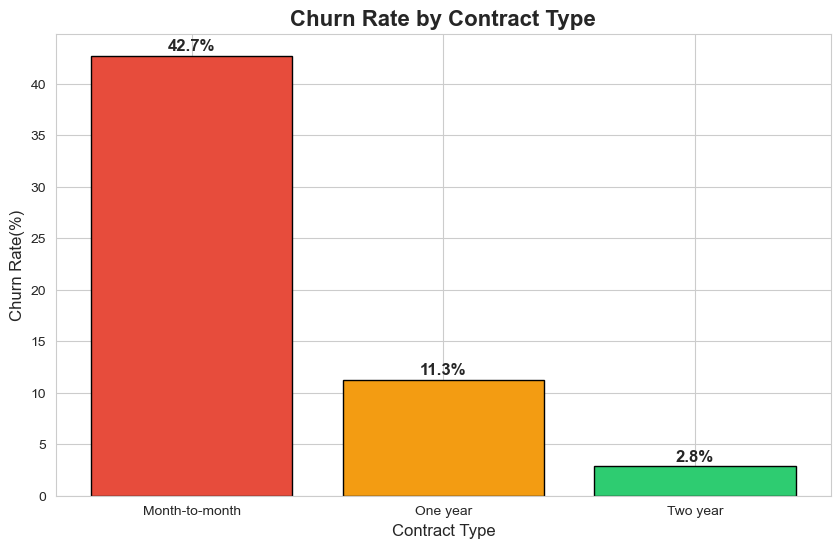

Chart 2 saved!


In [30]:
plt.figure(figsize = (10,6))
contract_churn = df.groupby('Contract')['Churn_Flag'].mean()*100
colors = ['#e74c3c','#f39c12','#2ecc71']
bars = plt.bar(contract_churn.index, contract_churn.values, color=colors, edgecolor='black')
plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize = 12)
plt.ylabel('Churn Rate(%)', fontsize = 12)
for bar, val in zip(bars, contract_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() +0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.savefig('chart2_contract_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 2 saved!")


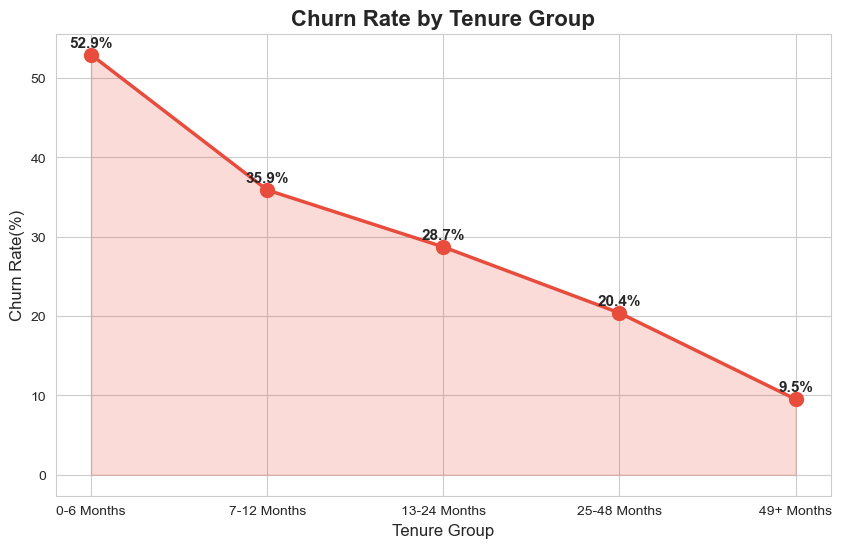

Chart 3 saved!


In [36]:
plt.figure(figsize=(10,6))
tenure_churn = df.groupby('Tenure_Group')['Churn_Flag'].mean()*100
tenure_order = ['0-6 Months', '7-12 Months', '13-24 Months', '25-48 Months', '49+ Months']
tenure_churn = tenure_churn.reindex(tenure_order)
plt.plot(tenure_churn.index, tenure_churn.values,
         marker='o', color='#e74c3c', linewidth=2.5, markersize=10)
plt.fill_between(range(len(tenure_churn)), tenure_churn.values, alpha=0.2, color='#e74c3c')
for i, val in enumerate(tenure_churn.values):
    plt.text(i,val + 1, f'{val:.1f}%', ha = 'center', fontsize=11, fontweight='bold')
plt.title('Churn Rate by Tenure Group', fontsize=16, fontweight='bold')
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Churn Rate(%)', fontsize=12)
plt.savefig('chart3_tenure_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 3 saved!')

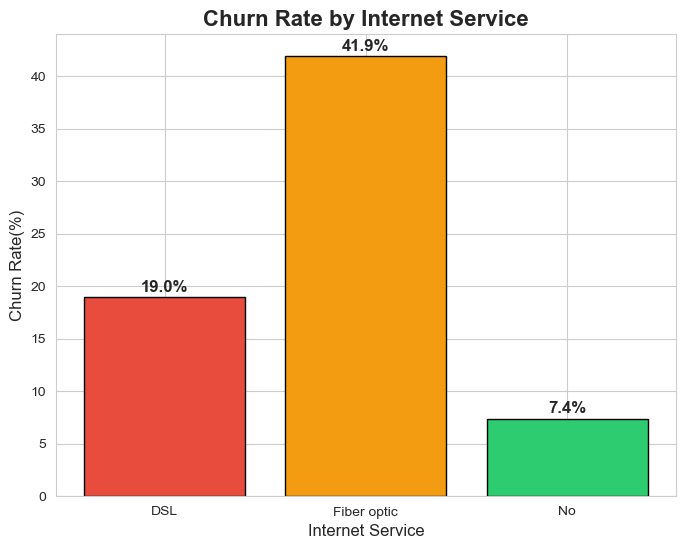

Chart 4 saved!


In [41]:
plt.figure(figsize=(8,6))
internet_churn = df.groupby('InternetService')['Churn_Flag'].mean()*100
color=['#3498db','#e74c3c', '#2ecc71']
bars = plt.bar(internet_churn.index, internet_churn.values, color=colors, edgecolor='black')
plt.title('Churn Rate by Internet Service', fontsize=16, fontweight='bold')
plt.xlabel('Internet Service', fontsize=12)
plt.ylabel('Churn Rate(%)', fontsize=12)
for bar, val in zip(bars, internet_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() +0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.savefig('chart4_tenure_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 4 saved!')

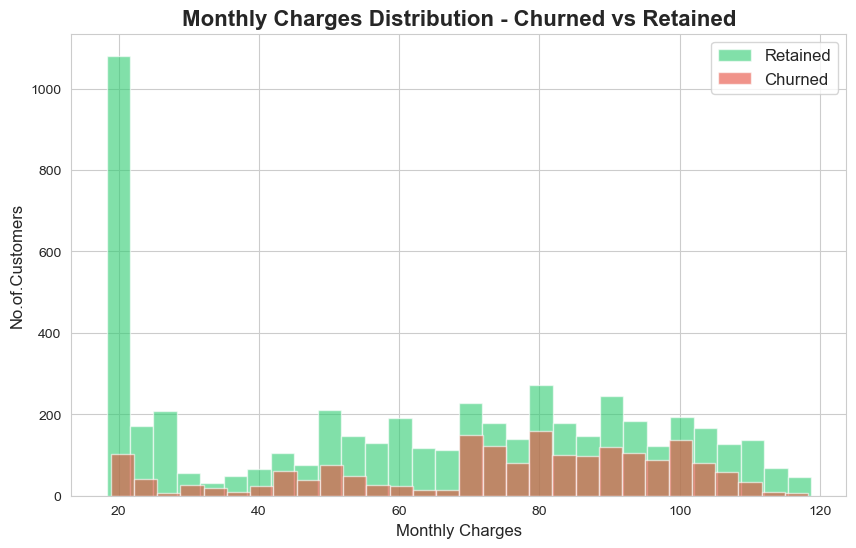

Chart 5 saved!


In [43]:
plt.figure(figsize = (10,6))
df[df['Churn']=='No']['MonthlyCharges'].hist(bins=30,alpha=0.6,
                                             color='#2ecc71', label='Retained')
df[df['Churn']=='Yes']['MonthlyCharges'].hist(bins=30, alpha=0.6,
                                              color='#e74c3c', label='Churned')
plt.title('Monthly Charges Distribution - Churned vs Retained', fontsize=16, fontweight='bold')
plt.xlabel('Monthly Charges', fontsize = 12)
plt.ylabel('No.of.Customers', fontsize = 12)
plt.legend(fontsize=12)
plt.savefig('chart5_contract_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 5 saved!")

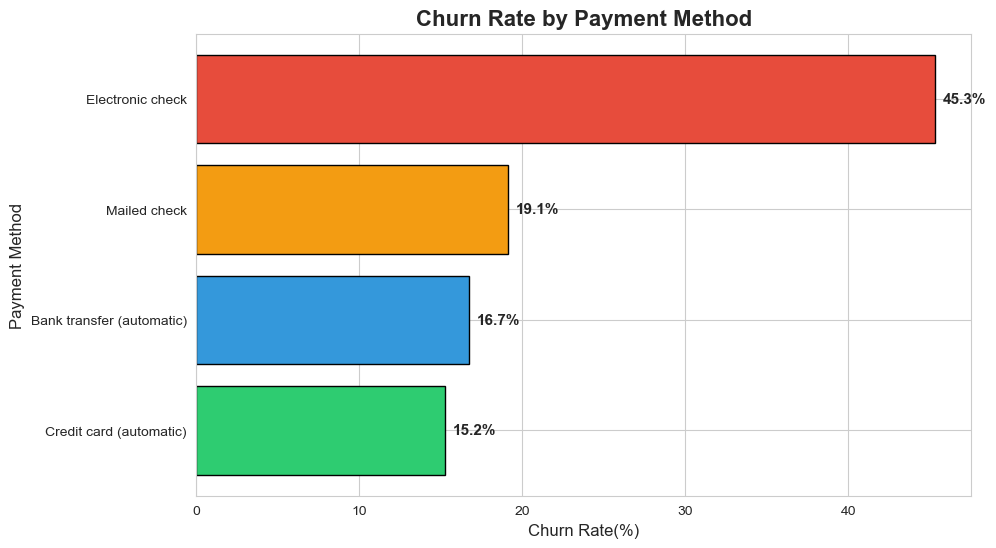

Chart 6 saved!


In [46]:
plt.figure(figsize=(10,6))
payment_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean()*100
payment_churn = payment_churn.sort_values(ascending=True)
colors=['#2ecc71','#3498db','#f39c12','#e74c3c']
bars = plt.barh(payment_churn.index, payment_churn.values, color=colors, edgecolor='black')
plt.title('Churn Rate by Payment Method', fontsize=16, fontweight='bold')
plt.xlabel('Churn Rate(%)', fontsize=12)
plt.ylabel('Payment Method', fontsize=12)
for bar, val in zip(bars, payment_churn.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
plt.savefig('chart6_payment_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 6 saved!')

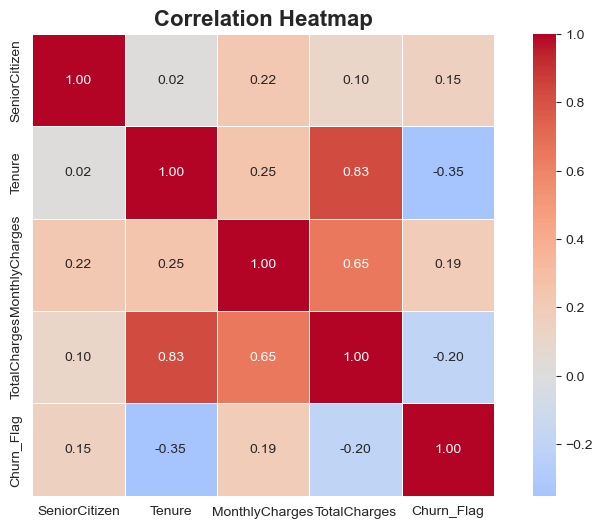

Chart 7 saved!


In [50]:
plt.figure(figsize=(10,6))
corr_cols = ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Flag']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.savefig('chart7_payment_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 7 saved!')

In [51]:
print("=" * 55)
print("    CUSTOMER CHURN ANALYSIS - KEY INSIGHTS")
print("=" * 55)

total = len(df)
churned = df['Churn_Flag'].sum()
churn_rate = df['Churn_Flag'].mean() * 100
revenue_lost = df[df['Churn']=='Yes']['MonthlyCharges'].sum()

print(f"\n Total Customers: {total:,}")
print(f"\n Total Chruned: {churned:,}")
print(f"\n Churn Rate: {churn_rate:.2f}%")
print(f"\n Monthly Revenue Lost: Rs.{revenue_lost:,.2f}")

print("\n---- TOP RISK FACTORS ----")
print("1. Month-to-month contracts --> 42.7% churn rate")
print("2. Fiber optic serive --> 41.9% churn rate")
print("3. New customer 0-6 months --> 52.9% churn rate")
print("4. Electronic check users --> 45.3% churn rate")
print("5. Higher monthly charge --> positive churn correlation(0.19)")

print("\n---- RECOMMENDATIONS ----")
print("1. Offer discount to convert month-to-month to annual contracts")
print("2. Improve fiber optic serive quality or review pricing")
print("3. Create onboarding program for first 6 months customers")
print("4. Incentivize customers to switch to automatic payments")
print("5. Target high_risk segments with proactive retention offers")
print("\n" + "=" * 55)

    CUSTOMER CHURN ANALYSIS - KEY INSIGHTS

 Total Customers: 7,043

 Total Chruned: 1,869

 Churn Rate: 26.54%

 Monthly Revenue Lost: Rs.139,130.85

---- TOP RISK FACTORS ----
1. Month-to-month contracts --> 42.7% churn rate
2. Fiber optic serive --> 41.9% churn rate
3. New customer 0-6 months --> 52.9% churn rate
4. Electronic check users --> 45.3% churn rate
5. Higher monthly charge --> positive churn correlation(0.19)

---- RECOMMENDATIONS ----
1. Offer discount to convert month-to-month to annual contracts
2. Improve fiber optic serive quality or review pricing
3. Create onboarding program for first 6 months customers
4. Incentivize customers to switch to automatic payments
5. Target high_risk segments with proactive retention offers

